In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from sklearn.cluster import KMeans
from sklearn import svm
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import r2_score
from typing import Sequence
from dataclasses import dataclass
from typing import NamedTuple
from typing import Mapping
from typing import TypeAlias

sys.path.append('C:\\Users\\Mark\\PycharmProjects\\approximationMap')

from control.experiment_data import ExperimentData


In [2]:
class Variant(NamedTuple):
    fuel_name: str
    additive_name: str
    component_name: str

@dataclass
class Variants:
    variant: Variant

def get_CO_vars() -> Sequence[Variants]:
    all_vars = ExperimentData().get_all_available_variations()
    CO_vars = [var for var in all_vars if var[2] == 'CO']
    return CO_vars
    

In [3]:
FuelCombination: TypeAlias = str

class ApproxData(NamedTuple):
    fuel_consumption: np.ndarray
    additive_consumption: np.ndarray
    approximated_surface: np.ndarray

def get_rbf_data() -> Mapping[FuelCombination, ApproxData]:
    CO_vars = get_CO_vars()
    rbf_data = {}
    
    for CO_var in CO_vars:
        var_name = '_'.join(CO_var)
        ex = ExperimentData()
        ex.get_experiment_data(*CO_var)
        rbf_data[var_name] = ex.get_rbf_data()
    return rbf_data
        

In [4]:
class DiffData(NamedTuple):
    fuel_consumption: np.ndarray
    additive_consumption: np.ndarray
    diff_surface: np.ndarray

def get_diff_data() -> Mapping[FuelCombination, DiffData]:
    rbf_data = get_rbf_data()
    diff_data = {}
    for fuel_combination in rbf_data:
        fuel_cons, add_cons, surf = rbf_data[fuel_combination]

        diff = np.abs(surf[5:] - surf[:-5])
        add_cons_diff = add_cons[5:]
        diff_data[fuel_combination] = fuel_cons, add_cons_diff, diff
    return diff_data


In [39]:
class LevelPoints(NamedTuple):
    x: np.ndarray
    y: np.ndarray

def get_contours(data: Mapping[FuelCombination, ApproxData | DiffData], contour_level) -> Mapping[FuelCombination, LevelPoints]:
    level_data = {}
    
    for fuel_combination in data:
        fig, ax = plt.subplots()
        
        x, y, surf = data[fuel_combination]
        contours = plt.contourf(x, y, surf, colors='none')
        selected_contour = contours.collections[contour_level]
        path = selected_contour.get_paths()[0]
        points = path.vertices

        level_x, level_y = points[:, 0], points[:, 1]
        level_data[fuel_combination] = level_x, level_y

        ax.remove()
        plt.close(fig)
    return level_data
    

C:\Users\Mark\AppData\Local\Temp\ipykernel_14368\2866873715.py:13: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[contour_level]


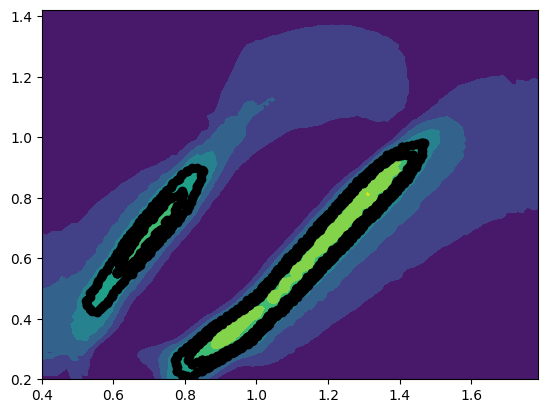

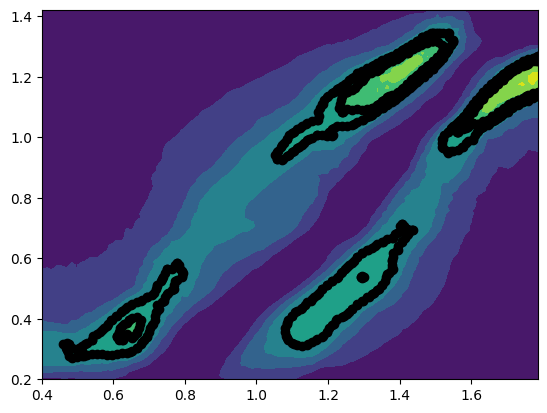

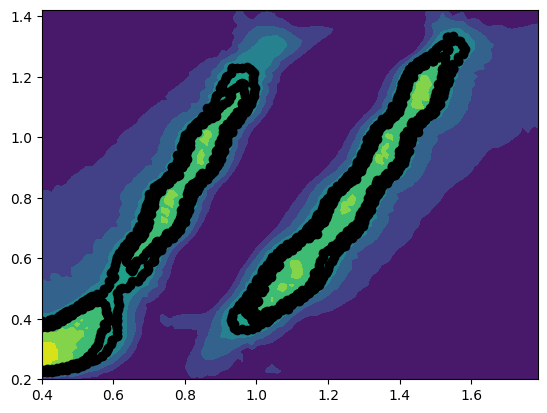

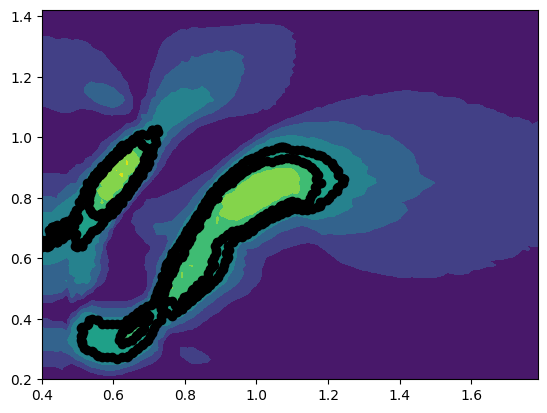

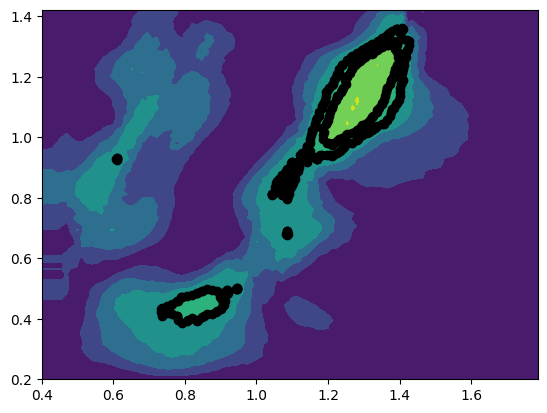

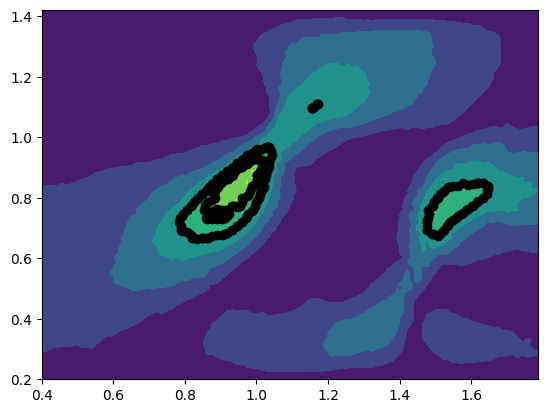

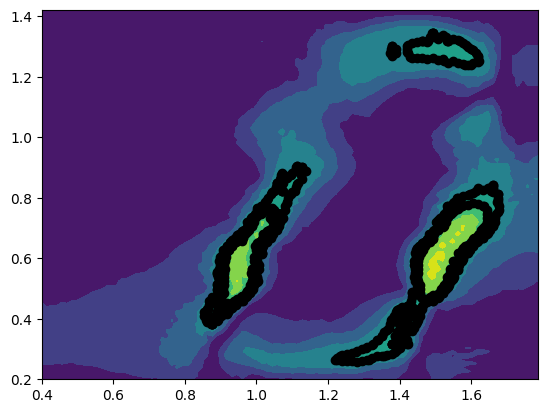

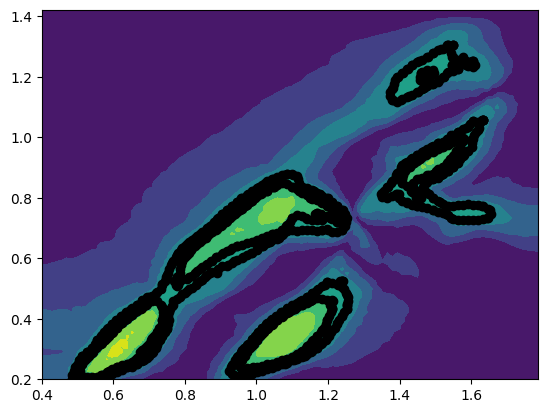

In [40]:
def show_contours(data: Mapping[FuelCombination, ApproxData | DiffData], contour_level) -> None:
    contour_data = get_contours(data, contour_level)
        
    for fuel_combination in data:
        x, y, surf = data[fuel_combination]
        x_level, y_level = contour_data[fuel_combination]
        
        plt.contourf(x, y, surf)

        plt.scatter(x_level, y_level, c='black')
        plt.show()
        plt.close()

show_contours(get_diff_data(), 4)

In [41]:
fuel_consumption: TypeAlias = float
additive_consumption: TypeAlias = float

class TrainLevelPoints(NamedTuple):
    points: list[list[fuel_consumption, additive_consumption]]
    point_type: list[int]

def get_train_data() -> Mapping[FuelCombination, TrainLevelPoints]:
    train_data = {
    'diesel_air_CO': (
        [[1.4, 0.9], [0.9, 0.3], [0.58, 0.47], [0.8, 0.8]], 
        [0, 0, 1, 1]
    ),
    'diesel_steam_CO': (
        [[1.6, 1], [1.2, 0.4], [1.4, 1.2], [0.6, 0.4]], 
        [0, 0, 1, 1]
    ),
    'crude_oil_steam_CO': (
        [[1.5, 1.2], [1.1, 0.6], [0.9, 1.1], [0.4, 0.3], [1, 1.25]], 
        [0, 0, 1, 1, 1]
    ),
    'heavy_oil_air_CO': (
        [[1.0, 0.8], [0.6, 0.3], [0.7, 1], [0.5, 0.75]], 
        [0, 0, 1, 1]
    ),
    'heavy_oil_steam_CO': (
        [[1.4, 1.3], [1.2, 1], [0.5, 0.8], [0.7, 1.1]], 
        [0, 0, 1, 1]
    ),
    'kerosene_air_CO': (
        [[1.3, 0.3], [1.5, 0.7], [1.4, 1.4], [0.4, 0.4]], 
        [0, 0, 1, 1]
    ),
    'kerosene_steam_CO': (
        [[1.6, 0.7], [1.4, 0.3], [1.2, 1.0], [0.8, 0.4]], 
        [0, 0, 1, 1]
    ),
    'waste_oil_steam_CO': (
        [[1.1, 0.3], [1.6, 0.8], [1.4, 0.8], [0.6, 0.2], [1.4, 1.2], [1.2, 0.7]], 
        [0, 0, 0, 1, 1, 1]
    ),}
    return train_data
    

C:\Users\Mark\AppData\Local\Temp\ipykernel_14368\2866873715.py:13: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[contour_level]


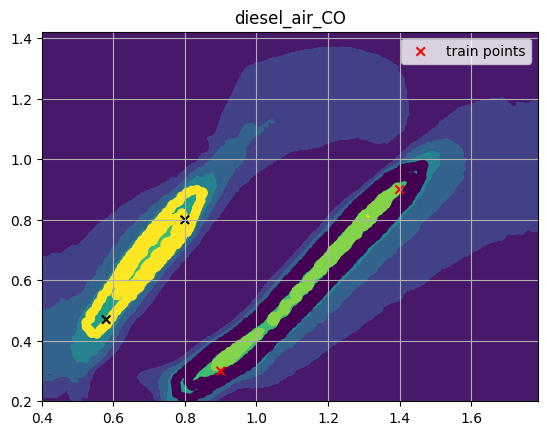

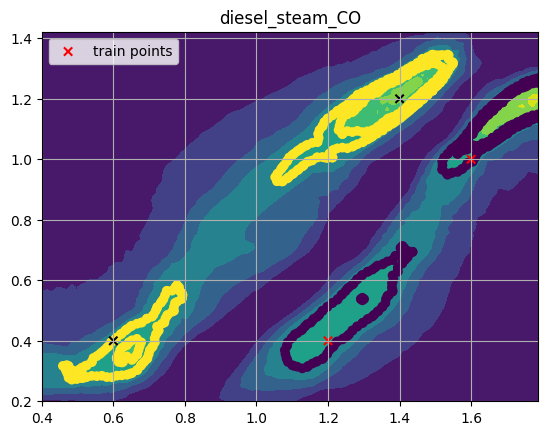

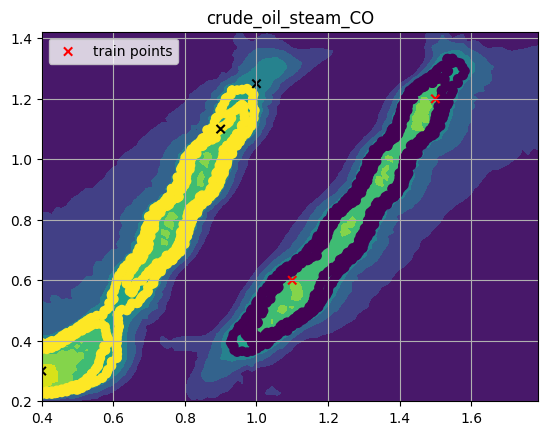

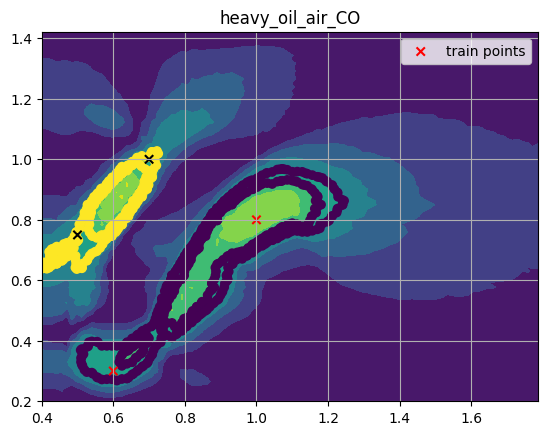

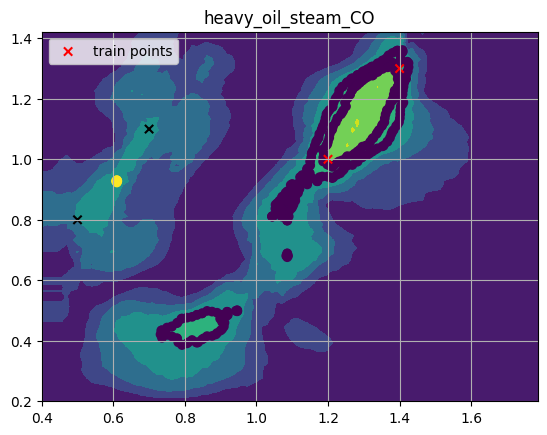

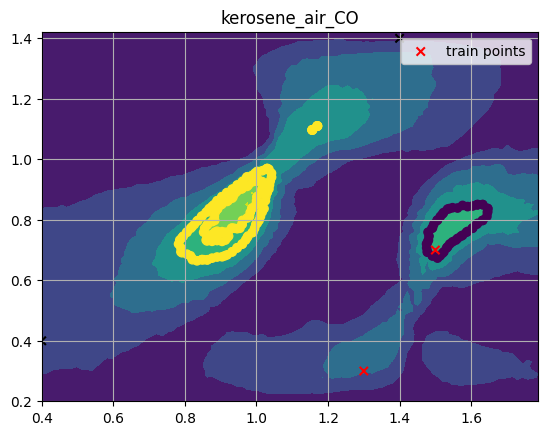

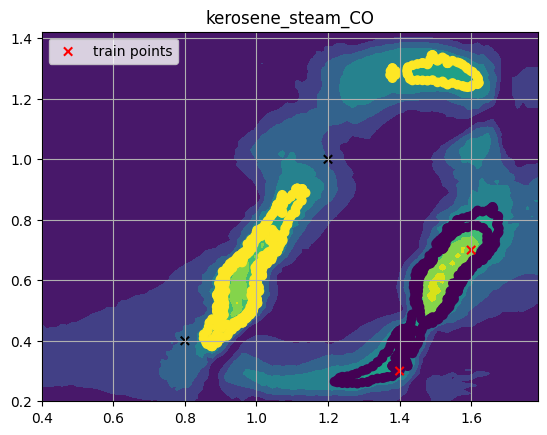

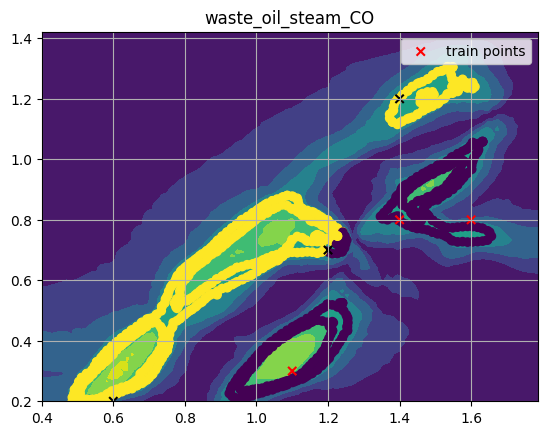

In [42]:
def show_classification_result(data: Mapping[FuelCombination, DiffData], contour_level: int) -> None:
    contour_data = get_contours(data, contour_level)
    train_data = get_train_data()
        
    for fuel_combination in data:
        x, y, surf = data[fuel_combination]
        xy_train, point_type = train_data[fuel_combination]
        x_level, y_level = contour_data[fuel_combination]
        
        clf = svm.LinearSVC(dual="auto").fit(xy_train, point_type)
   
        xy_level = [list(xy) for xy in zip(x_level, y_level)]

        clf_predict = clf.predict(xy_level)

        x_train = [xy[0] for xy in xy_train]
        y_train = [xy[1] for xy in xy_train]
        
        plt.contourf(x, y, surf)
        plt.scatter(x_level, y_level, c=clf_predict)
        plt.scatter(x_train, y_train, marker='x', c=['black' if type == 1 else 'red' for type in point_type], label='train points')
        
        plt.legend()
        plt.title(fuel_combination)
        plt.grid()
        
        plt.show()
        plt.close()
        
show_classification_result(get_diff_data(), 4)       

In [43]:
class LinearCoeffs(NamedTuple):
    a: float
    b: float

def _get_models(train_data: Mapping[FuelCombination, LevelPoints]) -> Mapping[FuelCombination, svm._classes.LinearSVC]:
    models = {}
    
    for fuel_combination in train_data:
        xy_train, point_type = train_data[fuel_combination]
        
        clf = svm.LinearSVC(dual="auto").fit(xy_train, point_type)
        models[fuel_combination] = clf
    return models

def _get_class(x: np.ndarray, y: np.ndarray, predicted_class: np.ndarray, class_number: int) -> LevelPoints:
    x_selected = []
    y_selected = []
    
    for i in range(len(predicted_class)):
        if predicted_class[i] == class_number:
            x_selected.append(x[i])
            y_selected.append(y[i])
    return np.array(x_selected), np.array(y_selected)

def _linear(x, a, b):
    return a * x + b
    

def get_linear_coeffs_grad(contour_data: Mapping[FuelCombination, LevelPoints]) -> Mapping[FuelCombination, LinearCoeffs]:
    coeffs = {}
    train_data = get_train_data()
    models = _get_models(train_data)

    for fuel_combination in contour_data:
        x_level, y_level = contour_data[fuel_combination]
        xy_level = [list(xy) for xy in zip(x_level, y_level)]
       
        clf = models[fuel_combination]
        clf_predict = clf.predict(xy_level)
        
        selected_x, selected_y = _get_class(x_level, y_level, clf_predict, 0)
        params, _ = curve_fit(_linear, selected_x, selected_y)
        a, b = params
        coeffs[fuel_combination] = a, b
    return coeffs

get_linear_coeffs_grad(get_contours(get_diff_data(), 4))

C:\Users\Mark\AppData\Local\Temp\ipykernel_14368\2866873715.py:13: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[contour_level]


{'diesel_air_CO': (1.108080061328729, -0.6644828672860821),
 'diesel_steam_CO': (1.4271365086260723, -1.2727857345761684),
 'crude_oil_steam_CO': (1.501792702634031, -1.0802456146186317),
 'heavy_oil_air_CO': (0.9559806298598701, -0.19987019352647403),
 'heavy_oil_steam_CO': (1.427494869165731, -0.7116563613425895),
 'kerosene_air_CO': (0.6267048250501233, -0.19988304479339425),
 'kerosene_steam_CO': (1.4035057082785767, -1.5428272474934208),
 'waste_oil_steam_CO': (1.1613687004346382, -0.8845928332035895)}

C:\Users\Mark\AppData\Local\Temp\ipykernel_14368\2866873715.py:13: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[contour_level]


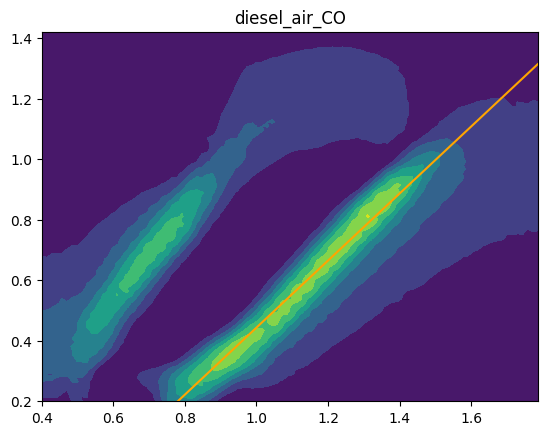

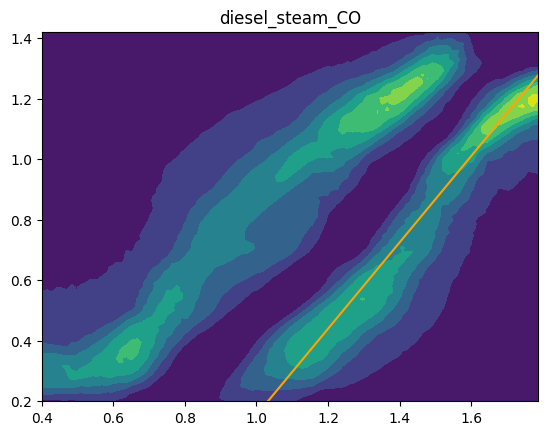

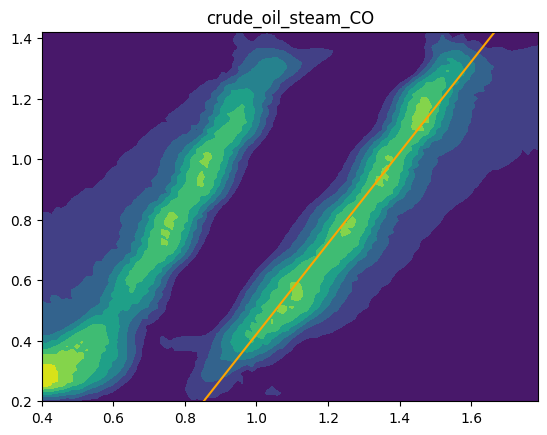

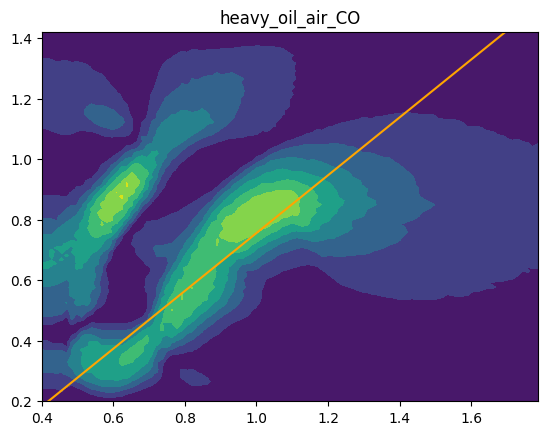

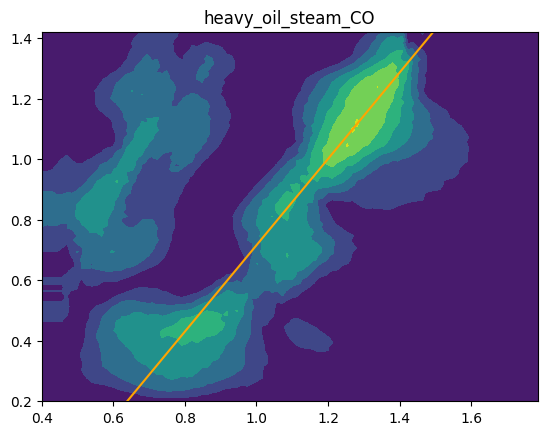

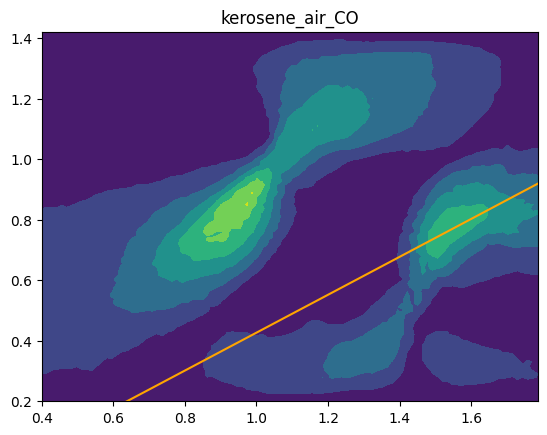

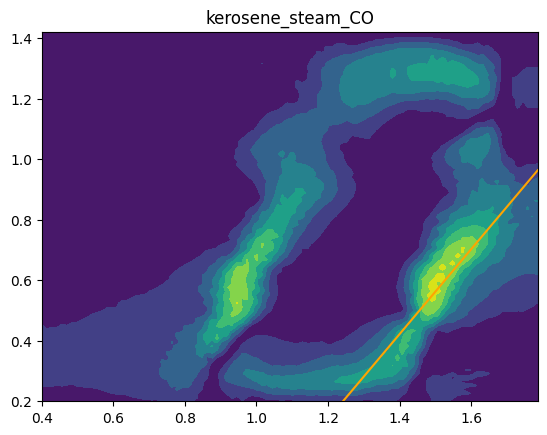

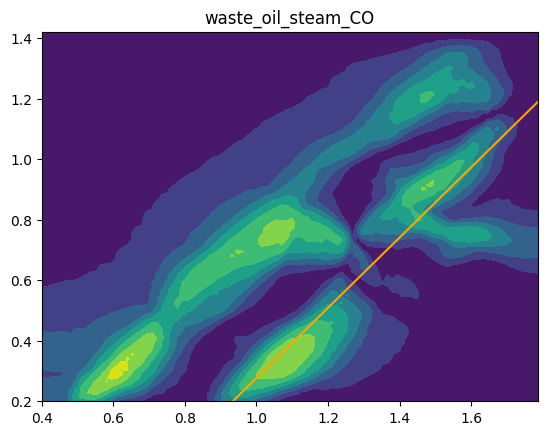

In [51]:
def show_approx_equations() -> None:
    diffs = get_diff_data()
    coeffs = get_linear_coeffs_grad(get_contours(diffs, 4))

    for fuel_combination in diffs:
        fuel_cons, add_cons_diff, diff = diffs[fuel_combination]
        approx = _linear(fuel_cons, *coeffs[fuel_combination])
        
        plt.title(fuel_combination)
        
        plt.contourf(fuel_cons, add_cons_diff, diff)
        plt.plot(fuel_cons, approx, c='orange')
        plt.ylim(min(add_cons_diff), max(add_cons_diff))
        plt.show()
        plt.close()

show_approx_equations()

In [54]:
class MinPoints(NamedTuple):
    x: np.ndarray
    y: np.ndarray

def _get_min_CO(data: Mapping[FuelCombination, ApproxData]) -> Mapping[FuelCombination, MinPoints]:
    min_CO = {}
    
    for fuel_combination in data:
        fuel, additive, surf = data[fuel_combination]
        df = pd.DataFrame(surf, columns=fuel, index=additive)
        df = df.idxmin(axis=1)
        min_x = list(df)
        min_y = list(df.index)
        min_CO[fuel_combination] = min_x, min_y
    return min_CO

def get_linear_coeffs_min_CO(data: Mapping[FuelCombination, ApproxData]) -> Mapping[FuelCombination, LinearCoeffs]:
    min_CO = _get_min_CO(data)
    coeffs = {}
    
    for fuel_combination in min_CO:
        min_x, min_y = min_CO[fuel_combination]
        params, _ = curve_fit(_linear, min_x, min_y)
        a, b = params
        coeffs[fuel_combination] = a, b
        
    return coeffs
        

get_linear_coeffs_min_CO(get_rbf_data())

{'diesel_air_CO': (1.7750695498901732, -0.957485568850631),
 'diesel_steam_CO': (1.2065019368447227, -0.6780678525859831),
 'crude_oil_steam_CO': (2.120400178850174, -1.1558677365957228),
 'heavy_oil_air_CO': (2.1690245413192275, -0.8634355530271459),
 'heavy_oil_steam_CO': (2.5388934022726994, -1.467299219012521),
 'kerosene_air_CO': (2.484089819501024, -2.267375362757524),
 'kerosene_steam_CO': (3.1166578740316484, -3.210087564123045),
 'waste_oil_steam_CO': (1.2140555996669573, -0.6622688786415072)}

In [56]:
def get_mean_coeffs(
    grad_coeffs: Mapping[FuelCombination, LinearCoeffs], 
    min_coeffs: Mapping[FuelCombination, LinearCoeffs]
) -> Mapping[FuelCombination, LinearCoeffs]:
    coeffs = {}
    
    for fuel_combination in min_coeffs:
        a = (grad_coeffs[fuel_combination][0] + min_coeffs[fuel_combination][0]) / 2
        b = (grad_coeffs[fuel_combination][1] + min_coeffs[fuel_combination][1]) / 2
        coeffs[fuel_combination] = a, b
    return coeffs
        
get_mean_coeffs(get_linear_coeffs_grad(get_contours(get_diff_data(), 4)), get_linear_coeffs_min_CO(get_rbf_data()))       

C:\Users\Mark\AppData\Local\Temp\ipykernel_14368\2866873715.py:13: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[contour_level]


{'diesel_air_CO': (1.441574805609451, -0.8109842180683565),
 'diesel_steam_CO': (1.3168192227353974, -0.9754267935810758),
 'crude_oil_steam_CO': (1.8110964407421024, -1.1180566756071773),
 'heavy_oil_air_CO': (1.5625025855895487, -0.53165287327681),
 'heavy_oil_steam_CO': (1.983194135719215, -1.0894777901775552),
 'kerosene_air_CO': (1.5553973222755735, -1.233629203775459),
 'kerosene_steam_CO': (2.2600817911551125, -2.3764574058082326),
 'waste_oil_steam_CO': (1.1877121500507979, -0.7734308559225483)}

C:\Users\Mark\AppData\Local\Temp\ipykernel_14368\2866873715.py:13: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[contour_level]


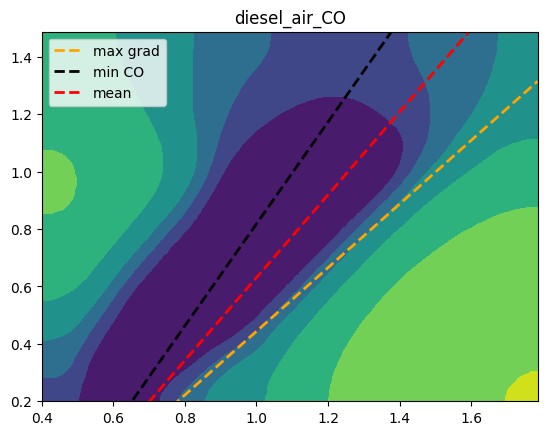

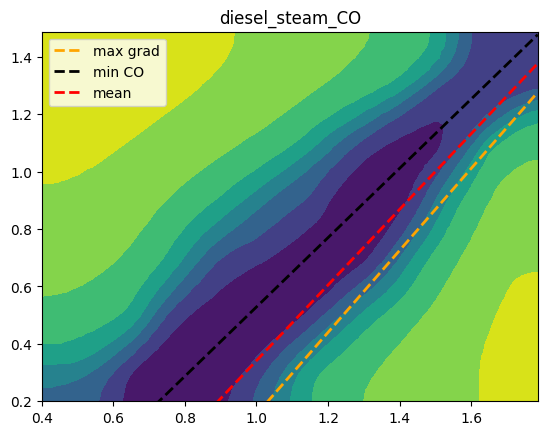

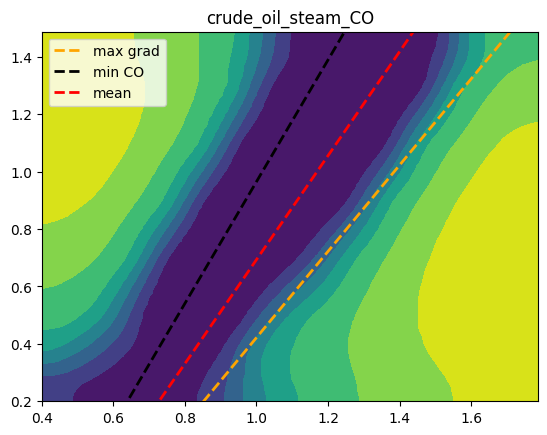

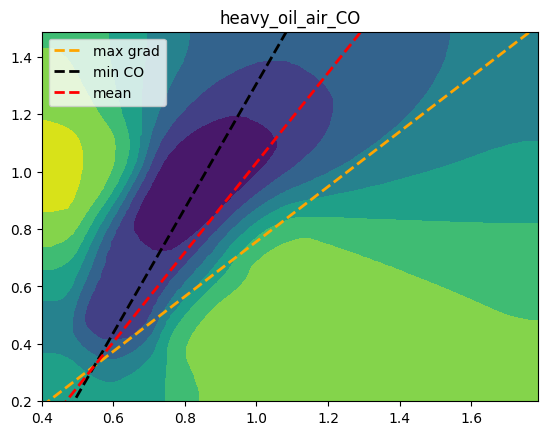

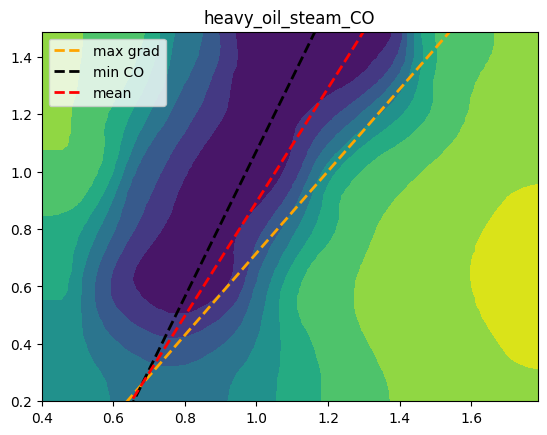

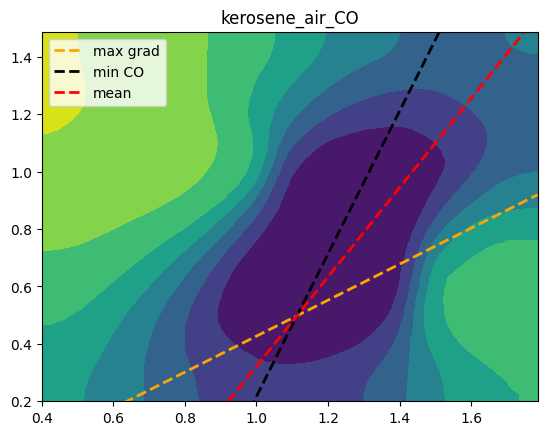

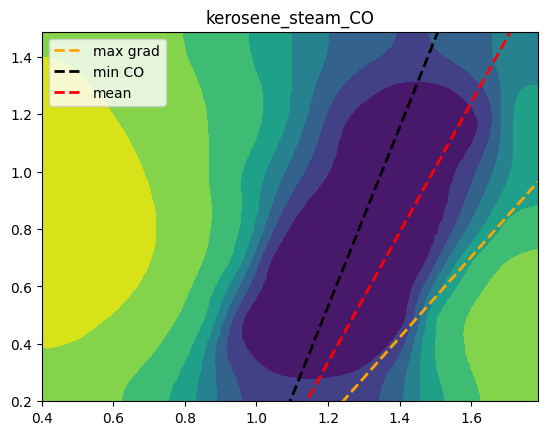

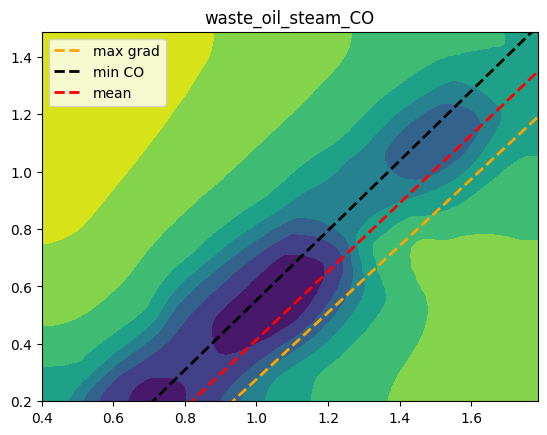

In [67]:
def show_result_equations() -> None:
    surfs = get_rbf_data()
    grad_coeffs = get_linear_coeffs_grad(get_contours(get_diff_data(), 4))
    min_coeffs = get_linear_coeffs_min_CO(get_rbf_data())
    mean_coeffs = get_mean_coeffs(grad_coeffs, min_coeffs)

    for fuel_combination in surfs:
        fuel_cons, add_cons_diff, diff = surfs[fuel_combination]
        grad_approx = _linear(fuel_cons, *grad_coeffs[fuel_combination])
        min_approx = _linear(fuel_cons, *min_coeffs[fuel_combination])
        mean_approx = _linear(fuel_cons, *mean_coeffs[fuel_combination])
        
        plt.contourf(*surfs[fuel_combination])
        plt.plot(fuel_cons, grad_approx, c='orange', linestyle='dashed', linewidth=2, label='max grad')
        plt.plot(fuel_cons, min_approx, c='black', linestyle='dashed', linewidth=2, label='min CO')
        plt.plot(fuel_cons, mean_approx, c='red', linestyle='dashed', linewidth=2, label='mean')
        plt.legend()
        plt.ylim(min(add_cons_diff), max(add_cons_diff))
        plt.title(fuel_combination)
        plt.show()
        plt.close()
        
                                          
show_result_equations() 